In [ ]:
import re
import json
from PIL import Image
from tqdm import tqdm

def read_json(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)
    return data

def save_to_json(data, filename):
    with open(filename, 'w', encoding='utf-8') as json_file:
        json.dump(data, json_file, indent=4, ensure_ascii=False)

single_graph_data = read_json("/mnt/pfs/jinfeng_team/MMGroup/lzz/code/CMMaTH/cmmath_v3.json")
def count_elements(data_list):
    total_elements = len(data_list)
    grade_group_counts = {1: 0, 2: 0, 3: 0}

    for item in data_list:
        grade_group = item.get("grade_group", "")
        if int(grade_group) in [1, 2, 3]:
            grade_group_counts[grade_group] += 1

    return total_elements, grade_group_counts

def count_subject(data_list):
    total_elements = len(data_list)
    subject_counts = {"Flow Chart": 0, "Bar Chart": 0, "Scatter Plot": 0,\
                      "Line Plot": 0, "Fan Chart":0, "LiDAR Chart":0, \
                      "Visual-Table":0, "Three View":0, "Three View":0, \
                      "Folded Image":0, "Analytic Geometry":0, "Solid Geometry":0,
                      "Plane Geometry":0, "Venn diagram":0, "Abtract Analogy diagram":0, "UnKnown":0}
    for item in data_list:
        mm_cls = item["metadata"]["multimodal-category"]
        if mm_cls in subject_counts.keys():
            subject_counts[mm_cls] += 1
        else:
            subject_counts["UnKnown"] += 1
    return total_elements, subject_counts

def clean_subject(data_list, cleaned_data_path):
    total_elements = len(data_list)
    data_list_cleaned = []
    subject_counts = {"Flow Chart": 0, "Bar Chart": 0, "Scatter Plot": 0,\
                      "Line Plot": 0, "Fan Chart":0, "LiDAR Chart":0, \
                      "Visual-Table":0, "Three View":0, "Three View":0, \
                      "Folded Image":0, "Analytic Geometry":0, "Solid Geometry":0,
                      "Plane Geometry":0, "Venn diagram":0, "Abtract Analogy diagram":0, "UnKnown":0}
    for item in data_list:
        mm_cls = item["metadata"]["multimodal-category"]
        if mm_cls in subject_counts.keys():
            subject_counts[mm_cls] += 1
            data_list_cleaned.append(item)
        else:
            subject_counts["UnKnown"] += 1
    save_to_json(data_list_cleaned, cleaned_data_path)

def clean_image_size(data_list, cleaned_data_path):
    total_elements = len(data_list)
    data_list_cleaned = []
    subject_counts = {"Flow Chart": 0, "Bar Chart": 0, "Scatter Plot": 0,\
                      "Line Plot": 0, "Fan Chart":0, "LiDAR Chart":0, \
                      "Visual-Table":0, "Three View":0, "Three View":0, \
                      "Folded Image":0, "Analytic Geometry":0, "Solid Geometry":0,
                      "Plane Geometry":0, "Venn diagram":0, "Abtract Analogy diagram":0, "UnKnown":0}
    for item in data_list:
        # import pdb; pdb.set_trace()
        image_height, image_width = item["metadata"]["img_info"][0]["height"], item["metadata"]["img_info"][0]["width"]
        if (float(image_height)>100) and (float(image_width)>100):
            data_list_cleaned.append(item)
    save_to_json(data_list_cleaned, cleaned_data_path)

def is_white_background(image_path):
    img = Image.open(image_path).convert('RGB')
    w, h = img.size
    corners = img.getpixel((0, 0)), img.getpixel((0, h-1)), img.getpixel((w-1, 0)), img.getpixel((w-1, h-1))
    white = (255, 255, 255)
    return any(corner == white for corner in corners)

def count_chinese_chars(string):
    count = 0
    for char in string:
        if '\u4e00' <= char <= '\u9fff':
            count += 1
    return count

def count_length_intervals(lengths):
    intervals = {"0-10": 0, "10-20": 0, "20-30": 0, "30-40": 0, "40-50": 0, "50-60": 0, "60-70": 0, ">70": 0}
    
    for length in lengths:
        if length >= 0 and length <= 10:
            intervals["0-10"] += 1
        elif length > 10 and length <= 20:
            intervals["10-20"] += 1
        elif length > 20 and length <= 30:
            intervals["20-30"] += 1
        elif length > 30 and length <= 40:
            intervals["30-40"] += 1
        elif length > 40 and length <= 50:
            intervals["40-50"] += 1
        elif length > 50 and length <= 60:
            intervals["50-60"] += 1
        elif length > 60 and length <= 70:
            intervals["60-70"] += 1
        else:
            intervals[">70"] += 1
            
    return intervals

def count_question_length(data_list):
    total_elements = len(data_list)
    question_len = []
    for item in data_list:
        len_cur = count_chinese_chars(item["question"])
        question_len.append(len_cur)
    return max(question_len), min(question_len), count_length_intervals(question_len)

def clean_background(data_list, cleaned_data_path):
    total_elements = len(data_list)
    data_list_cleaned = []
    import os
    image_root = "./images/"
    for item in tqdm(data_list):
        image_path = os.path.join(image_root, item["image"][0])
        try:
            if is_white_background(image_path):
                data_list_cleaned.append(item)
        except:
            pass
    save_to_json(data_list_cleaned, cleaned_data_path)

def count_knowledge(data_list):
    return 
    
print(count_subject(single_graph_data))
print(count_elements(single_graph_data))
print(count_question_length(single_graph_data))
# clean_background(single_graph_data, cleaned_data_path="./cmmath_v2_clean.json")
# clean_image_size(single_graph_data, cleaned_data_path="./cmmath_v2_clean.json")



(23854, {'Flow Chart': 3120, 'Bar Chart': 5164, 'Scatter Plot': 517, 'Line Plot': 846, 'Fan Chart': 175, 'LiDAR Chart': 73, 'Visual-Table': 1513, 'Three View': 1771, 'Folded Image': 235, 'Analytic Geometry': 3060, 'Solid Geometry': 2054, 'Plane Geometry': 3834, 'Venn diagram': 1052, 'Abtract Analogy diagram': 440, 'UnKnown': 0})
(23854, {1: 800, 2: 5082, 3: 17972})


In [2]:
import os
def get_filename_from_path(path):
    # 判断是否为路径
    # 获取尾部的文件名并去除后缀
    filename = os.path.basename(path)
    filename_without_extension = os.path.splitext(filename)[0]
    return filename_without_extension

path = "/mnt/pfs/jinfeng_team/MMGroup/lzz/huggingface_checkpoint/WizardMath-7B-V1.1"
print(get_filename_from_path(path))

KeyboardInterrupt: 

In [ ]:
import json
import random

def checkif_english_problem(item):
    text = item
    # 计算文本中英文字符的数量
    english_chars = sum(1 for char in text if char.isalpha() and ord(char) < 128)
    
    # 计算文本中的非英文字符数量
    non_english_chars = len(text) - english_chars
    
    # 如果文本中的英文字符数量超过非英文字符数量的一定比例，认为是英文描述
    try:
        english_ratio = english_chars / len(text)
        if english_ratio > 0.5:
            return True
        else:
            return False
    except:
        return False
    
def read_json(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)
    return data

def save_to_json(data, filename):
    with open(filename, 'w', encoding='utf-8') as json_file:
        json.dump(data, json_file, indent=4, ensure_ascii=False)

def sample_function(source_data, sample_size):
    target_data = []
    categories = set([d["metadata"]["multimodal-category"]  for d in source_data if checkif_english_problem(d["metadata"]["multimodal-category"])])
    for category in categories:
        category_data = [d for d in source_data if d["metadata"]["multimodal-category"] == category]
        num_samples = min(sample_size, len(category_data)) # Sample up to sample_size items
        sampled_data = random.sample(category_data, num_samples)
        target_data.extend(sampled_data)
    return target_data

write_path = "/mnt/pfs/jinfeng_team/MMGroup/lzz/code/CMMaTH/cmmath_testtoy_v2.json"
read_path = "/mnt/pfs/jinfeng_team/MMGroup/lzz/code/CMMaTH/cmmath_v2.json"
cmmath_data = read_json(read_path)
save_to_json(sample_function(cmmath_data, 100), write_path)

In [ ]:
import json
import random

def checkif_english_problem(item):
    text = item
    # 计算文本中英文字符的数量
    english_chars = sum(1 for char in text if char.isalpha() and ord(char) < 128)
    
    # 计算文本中的非英文字符数量
    non_english_chars = len(text) - english_chars
    
    # 如果文本中的英文字符数量超过非英文字符数量的一定比例，认为是英文描述
    try:
        english_ratio = english_chars / len(text)
        if english_ratio > 0.5:
            return True
        else:
            return False
    except:
        return False
    
def read_json(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)
    return data

def save_to_json(data, filename):
    with open(filename, 'w', encoding='utf-8') as json_file:
        json.dump(data, json_file, indent=4, ensure_ascii=False)

def overall_sample_function(source_data, sample_size):
    target_data = []
    num_samples = sample_size
    target_data.extend(random.sample(source_data, num_samples))
    return target_data

write_path = "/mnt/pfs/jinfeng_team/MMGroup/lzz/code/CMMaTH/cmmath_testmini_v3.json"
read_path = "/mnt/pfs/jinfeng_team/MMGroup/lzz/code/CMMaTH/cmmath_v3.json"
cmmath_data = read_json(read_path)
# save_to_json(sample_function(cmmath_data, 100), write_path)
save_to_json(overall_sample_function(cmmath_data, 1000), write_path)

In [ ]:
import os
import requests
import subprocess
from urllib.parse import urlparse
import json

convert_templete = "/Applications/Inkscape.app/Contents/MacOS/inkscape --export-type=png --export-background='#FFFFFF' --export-dpi=400 -o {png_filename} {svg_filename}"
def download_images(data):
    debug_index = 0
    for item in data:
        image_urls = item.get("image_url", [])
        image_names = item.get("image", [])
        for url, name in zip(image_urls, image_names):
            if url and name:
                response = requests.get(url)
                if response.status_code == 200:
                    # 判断URL是否指向图像文件
                    content_type = response.headers.get("content-type")
                    if content_type.startswith("image"):
                        # 解析URL获取文件扩展名
                        parsed_url = urlparse(url)
                        file_extension = os.path.splitext(parsed_url.path)[-1]
                        # 构建本地文件名
                        local_filename = name.split('.')[0]
                        if file_extension.lower() == ".svg":
                            # 如果是SVG格式，使用cairosvg进行转换
                            svg_filename = "images/"+local_filename + ".svg"
                            png_filename = "images/"+local_filename + ".png"
                            with open(svg_filename, "wb") as f:
                                f.write(response.content)
                            shell_convert_command = convert_templete.format_map(dict(png_filename=png_filename, svg_filename=svg_filename))
                            subprocess.run(['bash', '-c', shell_convert_command])
                            print(f"Downloaded and converted {png_filename} successfully!")
                            os.remove(svg_filename)  # 删除临时的SVG文件
                        else:
                            with open("images/"+local_filename+'.png', "wb") as f:
                                f.write(response.content)
                        print(f"Downloaded {local_filename} successfully!")
                    else:
                        print(f"URL {url} does not point to an image file")
                else:
                    print(f"Failed to download {name} from {url}")
        debug_index += 1

def read_json(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)
    return data

def save_to_json(data, filename):
    with open(filename, 'w', encoding='utf-8') as json_file:
        json.dump(data, json_file, indent=4, ensure_ascii=False)

def download_dataset_images(input_json):
    source_url_data = read_json(input_json)
    download_images(source_url_data)

input_json = "/mnt/pfs/jinfeng_team/MMGroup/lzz/code/CMMaTH/data_clean_workspace/clean_data/standard_single_graph_sec.json"
download_dataset_images(input_json=input_json)



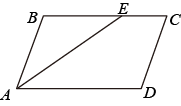

In [2]:
import base64
def image_to_base64(image_path):
    with open(image_path, 'rb') as image_file:
        base64_datas = base64.b64encode(image_file.read()).decode('utf-8')
    return f"data:image/png;base64,{base64_datas}"

url_img = image_to_base64("./images/s_02381_img_1.png")
print(url_img)

In [2]:
import re
import json

def read_json(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)
    return data


def save_to_json(data, filename):
    with open(filename, 'w', encoding='utf-8') as json_file:
        json.dump(data, json_file, indent=4, ensure_ascii=False)

data_1st_batch = read_json("./cmmath_s.json")
data_2st_batch = read_json("./cmmath_s_2st.json")
data_1st_batch.extend(data_2st_batch)
# print(len(data_1st_batch))
save_to_json(data_1st_batch, "./cmmath_v2.json") 